In [1]:
import numpy as np 

In [2]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

In [3]:
def gradient_descent(X, y, alpha, iterations):
    m,n = X.shape
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        z = X @ w + b
        f_wb = 1/(1+np.exp(-z))
        error = f_wb - y
        
        cost = (-1/m)*np.sum(y*np.log(f_wb) + (1-y)*np.log(1-f_wb))

        dj_dw = (1/m)* (X.T @ error)
        dj_db = (1/m)* np.sum(error)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i % 100 == 0:
            print(f"For {i} iterations: Cost = {cost}")

    return w, b

In [4]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_norm = (X_train - X_mean) / X_std

In [5]:
w, b = gradient_descent(X_train, y_train, alpha = 0.01, iterations=2000)

print(f"w: {w}, b: {b}")

For 0 iterations: Cost = 0.6931471805599452
For 100 iterations: Cost = 0.6509218027449559
For 200 iterations: Cost = 0.6334651157726543
For 300 iterations: Cost = 0.6185343464171902
For 400 iterations: Cost = 0.6044098201313357
For 500 iterations: Cost = 0.5908789621577482
For 600 iterations: Cost = 0.5778687744324835
For 700 iterations: Cost = 0.5653319330848501
For 800 iterations: Cost = 0.5532328869538419
For 900 iterations: Cost = 0.5415436130081128
For 1000 iterations: Cost = 0.5302412025518641
For 1100 iterations: Cost = 0.5193062889014596
For 1200 iterations: Cost = 0.508722002606186
For 1300 iterations: Cost = 0.49847327390964924
For 1400 iterations: Cost = 0.4885463653776364
For 1500 iterations: Cost = 0.478928557412293
For 1600 iterations: Cost = 0.46960793547120155
For 1700 iterations: Cost = 0.4605732450224834
For 1800 iterations: Cost = 0.45181379164704316
For 1900 iterations: Cost = 0.44331937124199094
w: [0.90586611 0.63261094], b: -1.831051994442152


In [6]:
z = X_train @ w + b
preds = (1 / (1 + np.exp(-z)) >= 0.5).astype(int)

print(preds)
print(y_train)

[0 0 0 1 1 1]
[0 0 0 1 1 1]


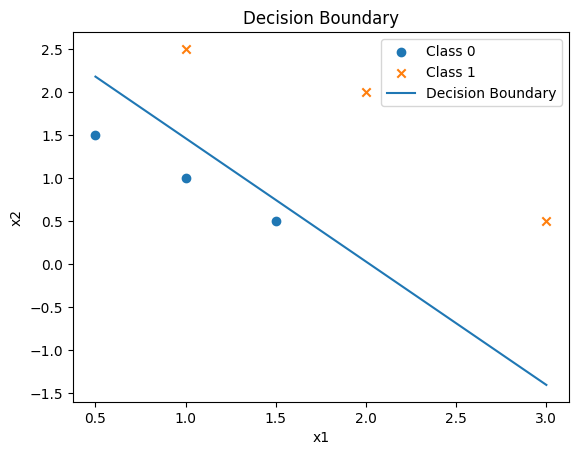

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# your data
X = X_train
y = y_train

# plot points
plt.scatter(X[y==0][:,0], X[y==0][:,1], marker='o', label='Class 0')
plt.scatter(X[y==1][:,0], X[y==1][:,1], marker='x', label='Class 1')

# decision boundary
x1_vals = np.linspace(min(X[:,0]), max(X[:,0]), 100)
x2_vals = -(w[0]*x1_vals + b) / w[1]

plt.plot(x1_vals, x2_vals, label='Decision Boundary')

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Decision Boundary")
plt.show()